<a href="https://colab.research.google.com/github/lokeshneerasa/Seaborn/blob/main/Cricket_Match_Analysis_using_Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Step 1 —  Import Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


**Set Seaborn Style:**

In [2]:
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)

# **Step 2 - Upload the Datasets**

In [4]:
from google.colab import files
uploaded=files.upload()

Saving deliveries.csv to deliveries.csv
Saving matches.csv to matches.csv


# **Step 3 — Load the datasets**

In [5]:
matches = pd.read_csv('/content/matches.csv')
deliveries = pd.read_csv('/content/deliveries.csv')

print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)

Matches shape: (15, 13)
Deliveries shape: (3600, 13)


# **Step 4 — View the datasets**

**Matches**

In [6]:
matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,winner,venue,player_of_match,win_by_runs,win_by_wickets
0,1,2020,Hyderabad,2020-09-19,Sunrisers Hyderabad,Royal Challengers Bangalore,Sunrisers Hyderabad,bat,Royal Challengers Bangalore,Rajiv Gandhi International Stadium,Virat Kohli,10,0
1,2,2020,Mumbai,2020-09-20,Mumbai Indians,Chennai Super Kings,Chennai Super Kings,field,Chennai Super Kings,Wankhede Stadium,MS Dhoni,0,5
2,3,2020,Delhi,2020-09-21,Delhi Capitals,Kolkata Knight Riders,Delhi Capitals,bat,Delhi Capitals,Arun Jaitley Stadium,Shreyas Iyer,18,0
3,4,2021,Bangalore,2021-04-09,Royal Challengers Bangalore,Mumbai Indians,Royal Challengers Bangalore,field,Royal Challengers Bangalore,M Chinnaswamy Stadium,AB de Villiers,0,2
4,5,2021,Chennai,2021-04-10,Chennai Super Kings,Delhi Capitals,Delhi Capitals,field,Delhi Capitals,MA Chidambaram Stadium,Rishabh Pant,0,7


**Deliveries**

In [7]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,batsman_runs,extra_runs,total_runs,is_wicket,dismissal_kind
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,Ruturaj Gaikwad,Ravindra Jadeja,4,0,4,0,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,Andre Russell,Mustafizur Rahman,0,0,0,0,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,KL Rahul,Kuldeep Yadav,1,0,1,0,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,Rishabh Pant,Mohammed Shami,1,0,1,0,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,Virat Kohli,Jasprit Bumrah,2,0,2,0,NaN


# **Step 5 — Check columns**

In [8]:
print("MATCHES COLUMNS")
print(matches.columns.tolist())

print("\nDELIVERIES COLUMNS")
print(deliveries.columns.tolist())

MATCHES COLUMNS
['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'venue', 'player_of_match', 'win_by_runs', 'win_by_wickets']

DELIVERIES COLUMNS
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'batsman_runs', 'extra_runs', 'total_runs', 'is_wicket', 'dismissal_kind']


# **Step 6 — Understand the data**

In [9]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               15 non-null     int64 
 1   season           15 non-null     int64 
 2   city             15 non-null     object
 3   date             15 non-null     object
 4   team1            15 non-null     object
 5   team2            15 non-null     object
 6   toss_winner      15 non-null     object
 7   toss_decision    15 non-null     object
 8   winner           15 non-null     object
 9   venue            15 non-null     object
 10  player_of_match  15 non-null     object
 11  win_by_runs      15 non-null     int64 
 12  win_by_wickets   15 non-null     int64 
dtypes: int64(4), object(9)
memory usage: 1.7+ KB


In [10]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   match_id        3600 non-null   int64 
 1   inning          3600 non-null   int64 
 2   batting_team    3600 non-null   object
 3   bowling_team    3600 non-null   object
 4   over            3600 non-null   int64 
 5   ball            3600 non-null   int64 
 6   batter          3600 non-null   object
 7   bowler          3600 non-null   object
 8   batsman_runs    3600 non-null   int64 
 9   extra_runs      3600 non-null   int64 
 10  total_runs      3600 non-null   int64 
 11  is_wicket       3600 non-null   int64 
 12  dismissal_kind  54 non-null     object
dtypes: int64(8), object(5)
memory usage: 365.8+ KB


# **Step 7 — Check missing values**

In [11]:
matches.isnull().sum()

,0
id,0
season,0
city,0
date,0
team1,0
team2,0
toss_winner,0
toss_decision,0
winner,0
venue,0


In [12]:
deliveries.isnull().sum()

,0
match_id,0
inning,0
batting_team,0
bowling_team,0
over,0
ball,0
batter,0
bowler,0
batsman_runs,0
extra_runs,0


# **Step 8 — Check duplicate records**

In [13]:
print("Duplicate matches:", matches.duplicated().sum())
print("Duplicate deliveries:", deliveries.duplicated().sum())

Duplicate matches: 0
Duplicate deliveries: 0


# **Step 9 — Basic statistics**

In [14]:
matches.describe(include='all')

,id,season,city,date,team1,team2,toss_winner,toss_decision,winner,venue,player_of_match,win_by_runs,win_by_wickets
count,15.000000,15.00000,15,15,15,15,15,15,15,15,15,15.000000,15.000000
unique,NaN,NaN,7,15,8,9,7,2,6,8,13,NaN,NaN
top,NaN,NaN,Mumbai,2020-09-19,Chennai Super Kings,Kolkata Knight Riders,Delhi Capitals,field,Royal Challengers Bangalore,Wankhede Stadium,Virat Kohli,NaN,NaN
freq,NaN,NaN,5,1,3,3,3,12,3,3,2,NaN,NaN
mean,8.000000,2022.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.333333,3.866667
std,4.472136,1.46385,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.710832,2.774029
min,1.000000,2020.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
25%,4.500000,2021.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000
50%,8.000000,2022.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,5.000000
75%,11.500000,2023.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,6.000000


In [15]:
deliveries.describe()

,match_id,inning,over,ball,batsman_runs,extra_runs,total_runs,is_wicket
count,3600.000000,3600.000000,3600.000000,3600.000000,3600.000000,3600.00000,3600.000000,3600.000000
mean,8.000000,1.500000,10.500000,3.500000,1.746667,0.06000,1.806667,0.015000
std,4.321094,0.500069,5.767082,1.708062,1.550212,0.23752,1.592864,0.121569
min,1.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000
25%,4.000000,1.000000,5.750000,2.000000,1.000000,0.00000,1.000000,0.000000
50%,8.000000,1.500000,10.500000,3.500000,1.000000,0.00000,1.000000,0.000000
75%,12.000000,2.000000,15.250000,5.000000,2.000000,0.00000,2.000000,0.000000
max,15.000000,2.000000,20.000000,6.000000,6.000000,1.00000,7.000000,1.000000


# **Step 10 — Number of matches**

In [16]:
total_matches = matches['id'].nunique()

print("Total Matches:", total_matches)

Total Matches: 15


# **Step 11 — Matches by season**

In [17]:
matches_per_season = matches.groupby('season')['id'].nunique()

print(matches_per_season)

season
2020    3
2021    3
2022    3
2023    3
2024    3
Name: id, dtype: int64


**Seaborn visualization**

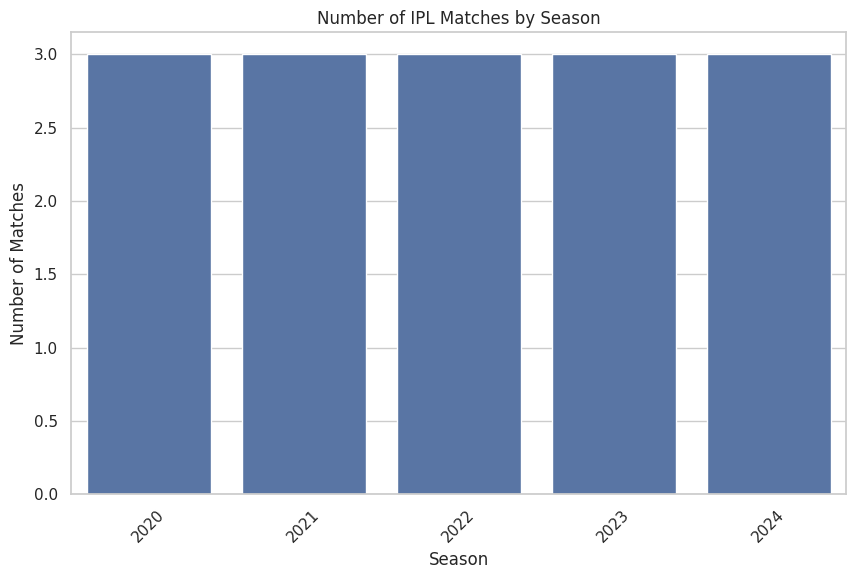

In [18]:
season_df = matches_per_season.reset_index()

sns.barplot(
    data=season_df,
    x='season',
    y='id'
)

plt.title('Number of IPL Matches by Season')
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45)
plt.show()

# **Step 12 — Matches won by each team**

In [19]:
winner_counts = matches['winner'].value_counts()

print(winner_counts)

winner
Royal Challengers Bangalore    3
Delhi Capitals                 3
Gujarat Titans                 3
Kolkata Knight Riders          3
Chennai Super Kings            2
Rajasthan Royals               1
Name: count, dtype: int64


**Visualize:**

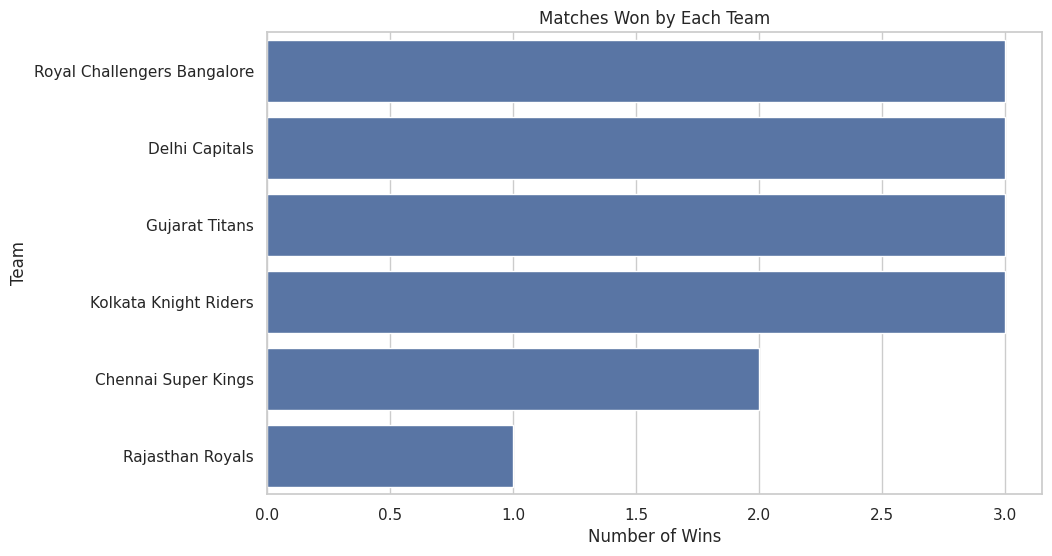

In [20]:
winner_df = winner_counts.reset_index()

winner_df.columns = ['Team', 'Wins']

sns.barplot(
    data=winner_df,
    x='Wins',
    y='Team'
)

plt.title('Matches Won by Each Team')
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.show()

# **Step 13 — Toss decision analysis**

In [21]:
toss_decisions = matches['toss_decision'].value_counts()

print(toss_decisions)

toss_decision
field    12
bat       3
Name: count, dtype: int64


**Visualize:**

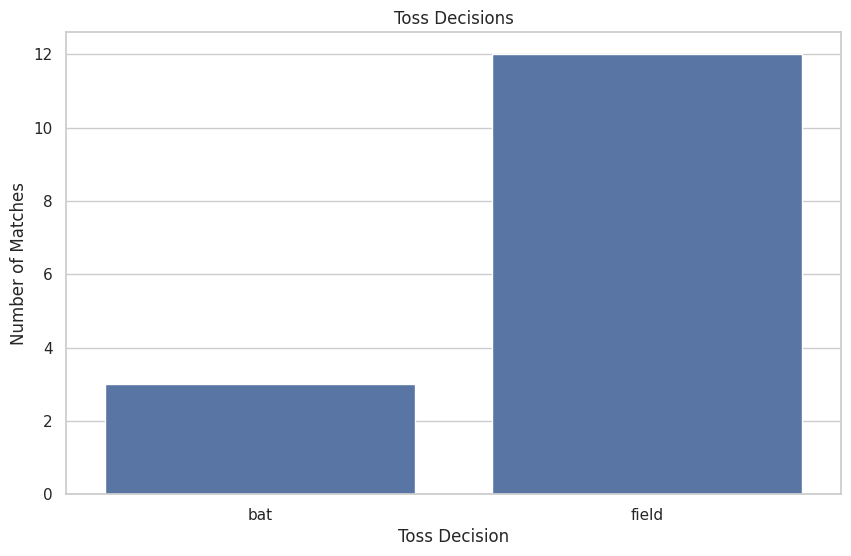

In [22]:
sns.countplot(
    data=matches,
    x='toss_decision'
)

plt.title('Toss Decisions')
plt.xlabel('Toss Decision')
plt.ylabel('Number of Matches')
plt.show()

# **Step 14 — Toss winner vs match winner**

In [23]:
matches['toss_match_winner'] = (
    matches['toss_winner'] == matches['winner']
)

**Calculate:**

In [24]:
toss_result = matches['toss_match_winner'].value_counts()

print(toss_result)

toss_match_winner
True     14
False     1
Name: count, dtype: int64


**Visualization:**

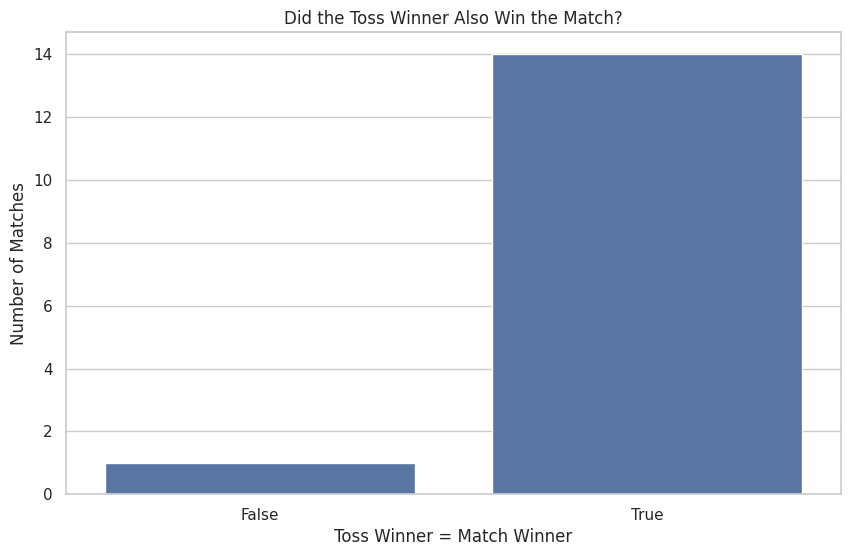

In [25]:
sns.countplot(
    data=matches,
    x='toss_match_winner'
)

plt.title('Did the Toss Winner Also Win the Match?')
plt.xlabel('Toss Winner = Match Winner')
plt.ylabel('Number of Matches')
plt.show()

# **Step 15 — Toss decision by season**

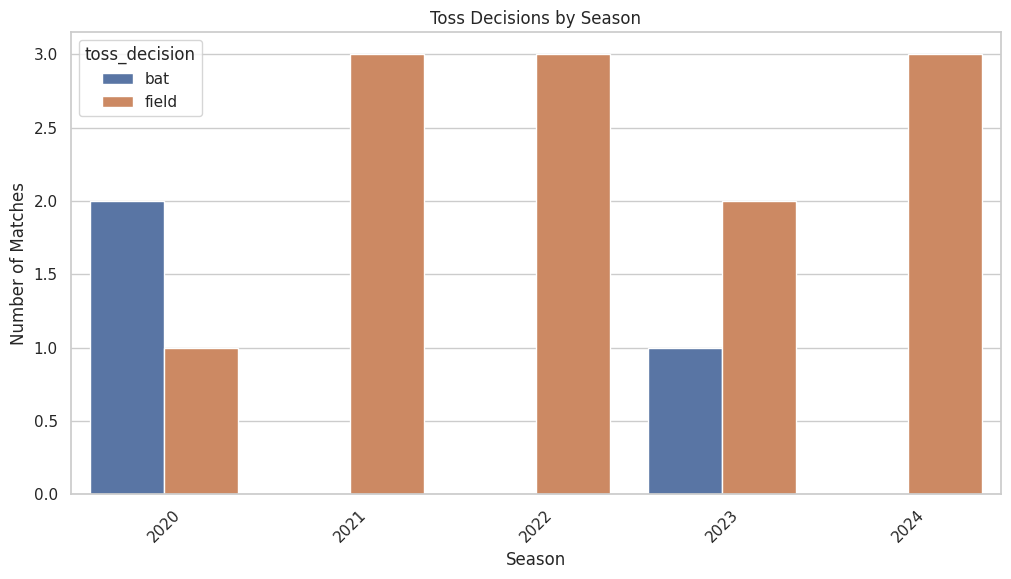

In [26]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=matches,
    x='season',
    hue='toss_decision'
)

plt.title('Toss Decisions by Season')
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45)
plt.show()

# **Step 16 — Most common venues**

In [27]:
venue_counts = matches['venue'].value_counts().head(10)

print(venue_counts)

venue
Wankhede Stadium                      3
Narendra Modi Stadium                 3
M Chinnaswamy Stadium                 2
Rajiv Gandhi International Stadium    2
MA Chidambaram Stadium                2
Arun Jaitley Stadium                  1
Brabourne Stadium                     1
Eden Gardens                          1
Name: count, dtype: int64


**Visualization:**

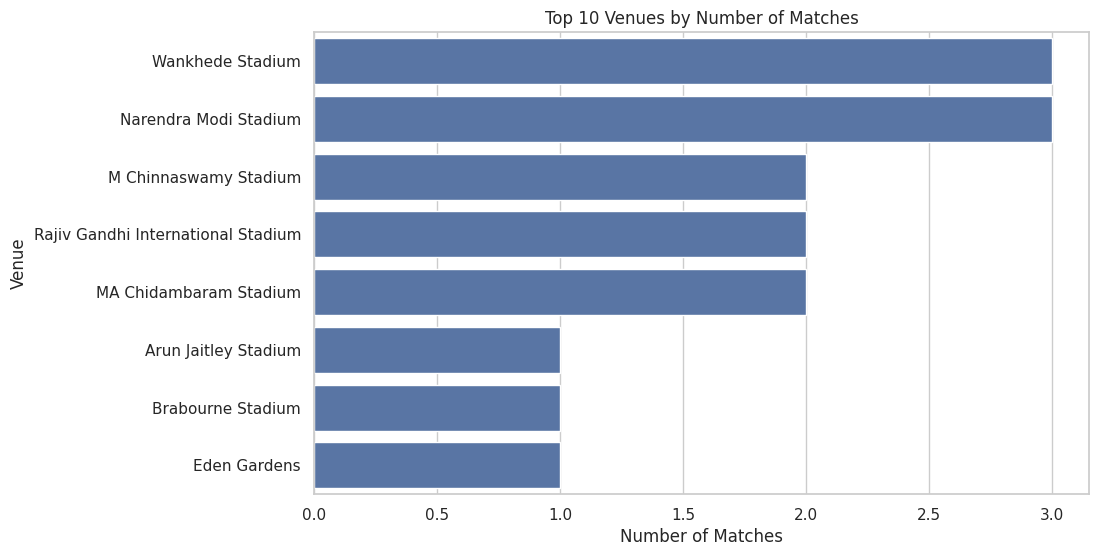

In [28]:
venue_df = venue_counts.reset_index()

venue_df.columns = ['Venue', 'Matches']

sns.barplot(
    data=venue_df,
    x='Matches',
    y='Venue'
)

plt.title('Top 10 Venues by Number of Matches')
plt.xlabel('Number of Matches')
plt.ylabel('Venue')
plt.show()

# **Step 17 — Player of the Match analysis**

In [29]:
pom_counts = matches['player_of_match'].value_counts().head(10)

print(pom_counts)

player_of_match
Virat Kohli       2
Rashid Khan       2
MS Dhoni          1
AB de Villiers    1
Shreyas Iyer      1
Rishabh Pant      1
Nitish Rana       1
Kuldeep Yadav     1
Umesh Yadav       1
Rahul Tewatia     1
Name: count, dtype: int64


**Visualize:**

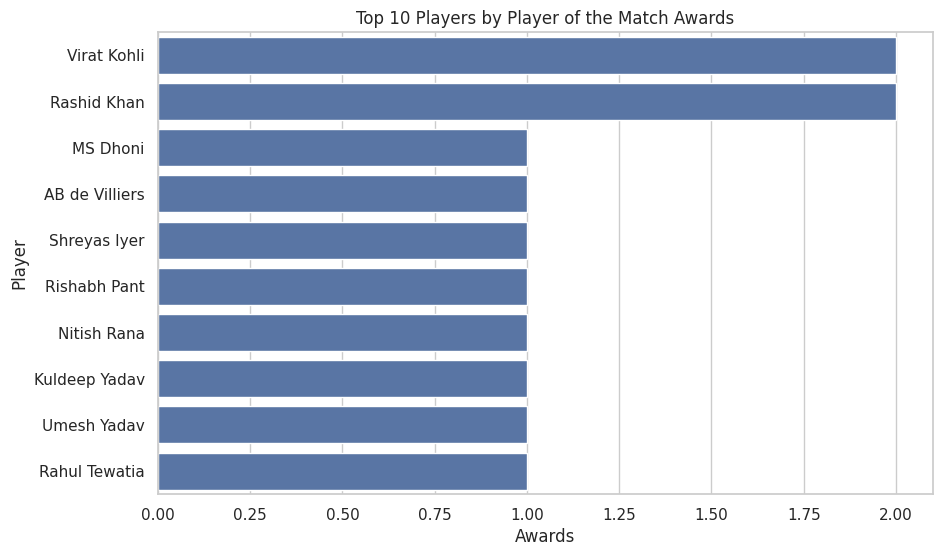

In [30]:
pom_df = pom_counts.reset_index()

pom_df.columns = ['Player', 'Awards']

sns.barplot(
    data=pom_df,
    x='Awards',
    y='Player'
)

plt.title('Top 10 Players by Player of the Match Awards')
plt.xlabel('Awards')
plt.ylabel('Player')
plt.show()

# **Step 18 — Prepare batting data**

Now we start using the deliveries.csv dataset.

In [31]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,batsman_runs,extra_runs,total_runs,is_wicket,dismissal_kind
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,Ruturaj Gaikwad,Ravindra Jadeja,4,0,4,0,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,Andre Russell,Mustafizur Rahman,0,0,0,0,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,KL Rahul,Kuldeep Yadav,1,0,1,0,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,Rishabh Pant,Mohammed Shami,1,0,1,0,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,Virat Kohli,Jasprit Bumrah,2,0,2,0,NaN


**Calculate total runs by batter:**

In [32]:
batter_runs = (
    deliveries
    .groupby('batter')['batsman_runs']
    .sum()
    .sort_values(ascending=False)
)

**Display top 10:**

In [33]:
print(batter_runs.head(10))

batter
Yashasvi Jaiswal    672
MS Dhoni            672
Virat Kohli         672
Ruturaj Gaikwad     672
Rishabh Pant        624
Shubman Gill        624
Rohit Sharma        600
KL Rahul            600
Andre Russell       576
AB de Villiers      576
Name: batsman_runs, dtype: int64


# **Step 19 — Top 10 run scorers**

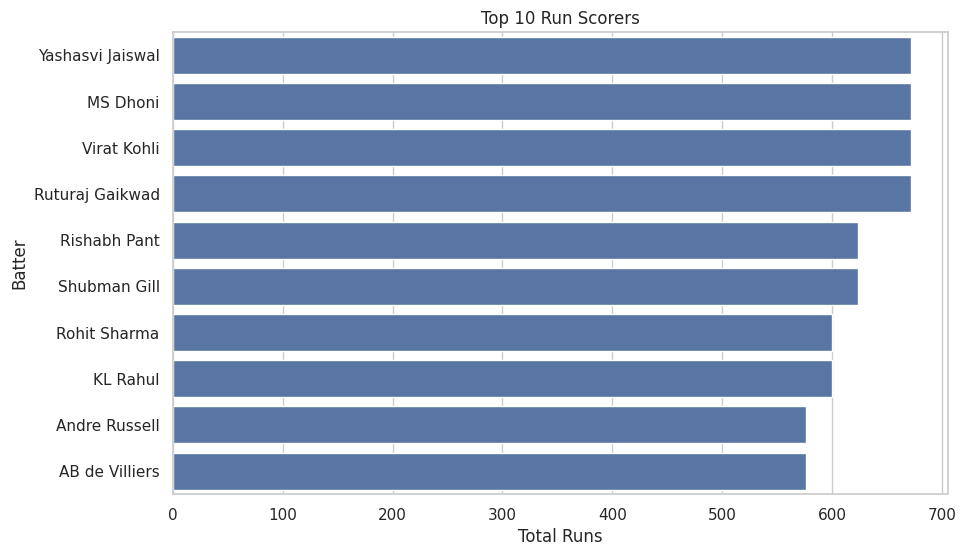

In [34]:
top_batters = batter_runs.head(10).reset_index()

top_batters.columns = ['Batter', 'Runs']

sns.barplot(
    data=top_batters,
    x='Runs',
    y='Batter'
)

plt.title('Top 10 Run Scorers')
plt.xlabel('Total Runs')
plt.ylabel('Batter')
plt.show()

# **Step 20 — Runs by team**

In [35]:
team_runs = (
    deliveries
    .groupby('batting_team')['total_runs']
    .sum()
    .sort_values(ascending=False)
)

print(team_runs)

batting_team
Chennai Super Kings            1088
Mumbai Indians                 1087
Kolkata Knight Riders           874
Royal Challengers Bangalore     854
Delhi Capitals                  659
Gujarat Titans                  656
Sunrisers Hyderabad             637
Lucknow Super Giants            220
Punjab Kings                    220
Rajasthan Royals                209
Name: total_runs, dtype: int64


**Visualization:**

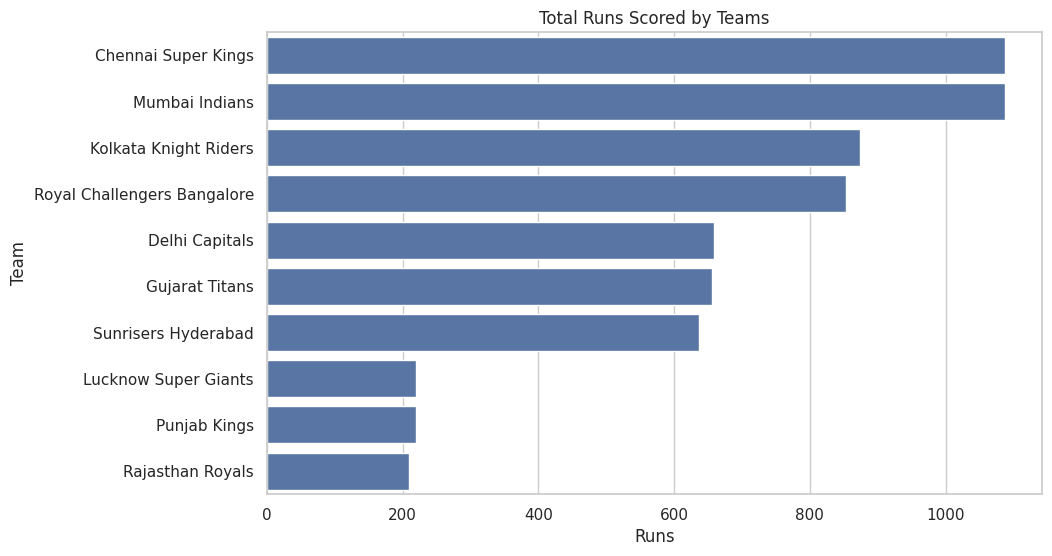

In [36]:
team_runs_df = team_runs.reset_index()

team_runs_df.columns = ['Team', 'Runs']

sns.barplot(
    data=team_runs_df,
    x='Runs',
    y='Team'
)

plt.title('Total Runs Scored by Teams')
plt.xlabel('Runs')
plt.ylabel('Team')
plt.show()

# **Step 21 — Analyze boundaries**

**Calculate fours:**

In [37]:
fours = deliveries[
    deliveries['batsman_runs'] == 4
]

**Count by batter:**

In [38]:
four_counts = (
    fours
    .groupby('batter')
    .size()
    .sort_values(ascending=False)
)

print(four_counts.head(10))

batter
Yashasvi Jaiswal    84
MS Dhoni            84
Virat Kohli         84
Ruturaj Gaikwad     84
Andre Russell       60
AB de Villiers      60
Rohit Sharma        60
Rishabh Pant        60
KL Rahul            60
Shubman Gill        60
dtype: int64


# **Step 22 — Top 10 players by fours**

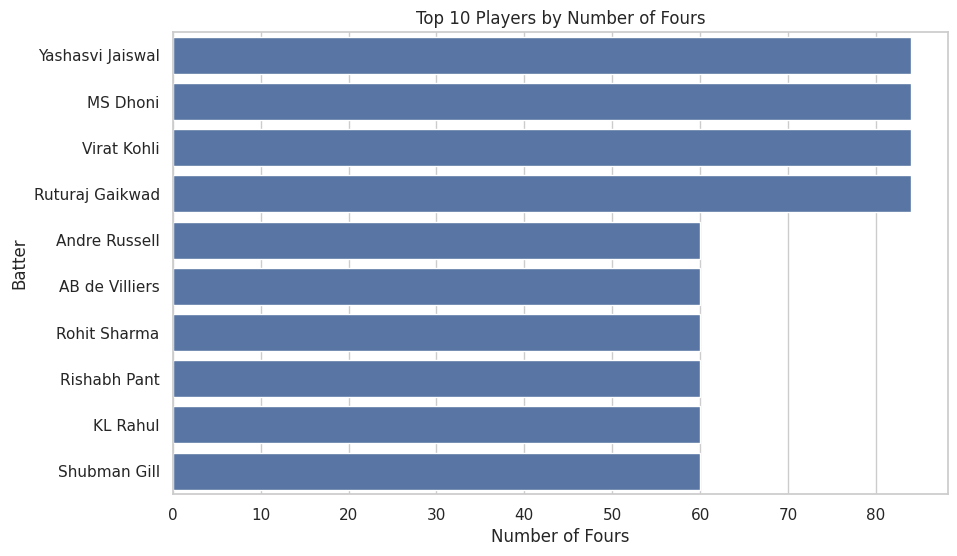

In [39]:
four_df = four_counts.head(10).reset_index()

four_df.columns = ['Batter', 'Fours']

sns.barplot(
    data=four_df,
    x='Fours',
    y='Batter'
)

plt.title('Top 10 Players by Number of Fours')
plt.xlabel('Number of Fours')
plt.ylabel('Batter')
plt.show()

# **Step 23 — Analyze sixes**

In [40]:
sixes = deliveries[
    deliveries['batsman_runs'] == 6
]

**Count sixes:**

In [41]:
six_counts = (
    sixes
    .groupby('batter')
    .size()
    .sort_values(ascending=False)
)

print(six_counts.head(10))

batter
AB de Villiers      12
Andre Russell       12
KL Rahul            12
MS Dhoni            12
Rishabh Pant        12
Rohit Sharma        12
Ruturaj Gaikwad     12
Shubman Gill        12
Virat Kohli         12
Yashasvi Jaiswal    12
dtype: int64


**Visualization:**

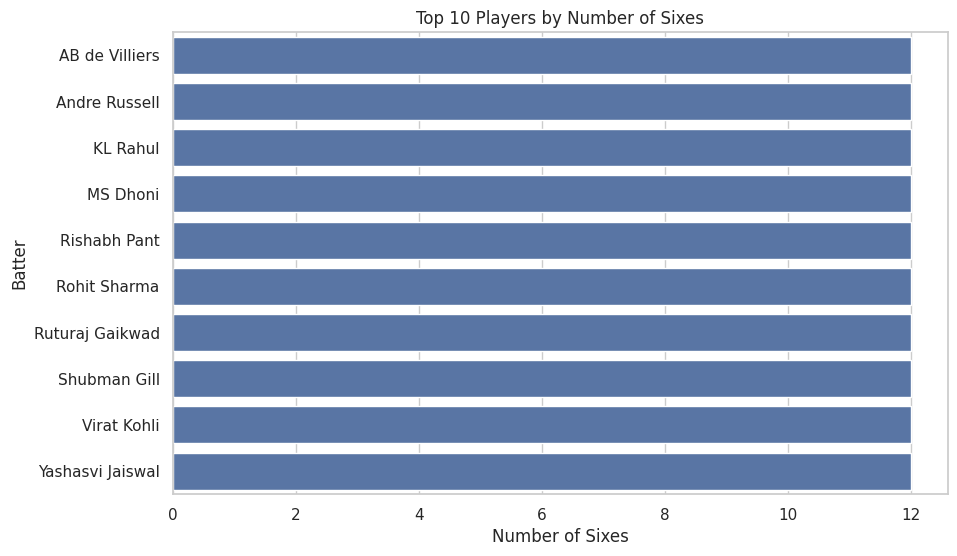

In [42]:
six_df = six_counts.head(10).reset_index()

six_df.columns = ['Batter', 'Sixes']

sns.barplot(
    data=six_df,
    x='Sixes',
    y='Batter'
)

plt.title('Top 10 Players by Number of Sixes')
plt.xlabel('Number of Sixes')
plt.ylabel('Batter')
plt.show()

# **Step 24 — Top wicket takers**

**Filter wickets:**

In [43]:
wickets = deliveries[
    deliveries['is_wicket'] == 1
]

In [44]:
bowler_wickets = deliveries[
    (deliveries['is_wicket'] == 1) &
    (~deliveries['dismissal_kind'].isin([
        'run out',
        'retired hurt',
        'obstructing the field'
    ]))
]

In [45]:
wicket_counts = (
    bowler_wickets
    .groupby('bowler')
    .size()
    .sort_values(ascending=False)
)

print(wicket_counts.head(10))

bowler
Jasprit Bumrah       9
Kuldeep Yadav        9
Umesh Yadav          8
Mohammed Siraj       7
Ravindra Jadeja      7
Mohammed Shami       6
Rashid Khan          4
Mustafizur Rahman    4
dtype: int64


# **Step 25 — Wicket taker visualization**

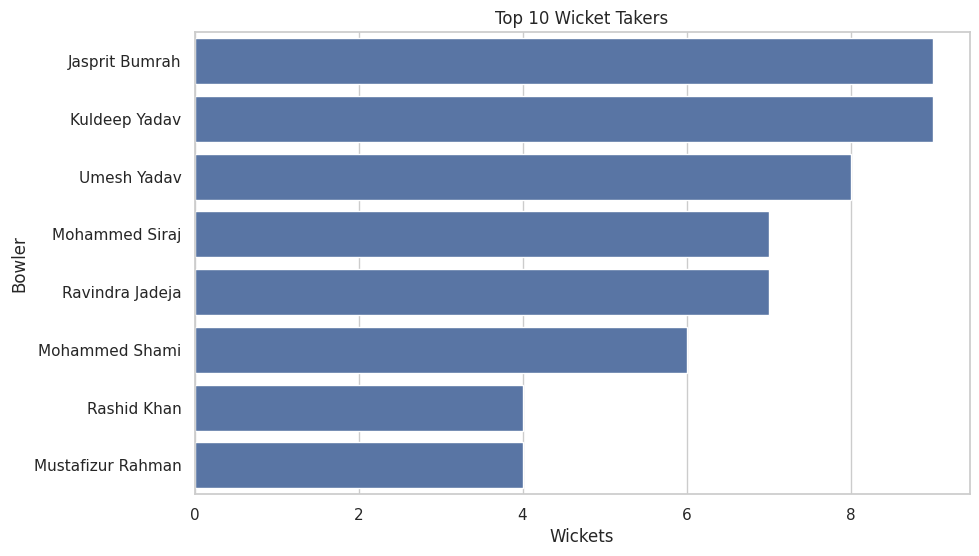

In [46]:
wicket_df = wicket_counts.head(10).reset_index()

wicket_df.columns = ['Bowler', 'Wickets']

sns.barplot(
    data=wicket_df,
    x='Wickets',
    y='Bowler'
)

plt.title('Top 10 Wicket Takers')
plt.xlabel('Wickets')
plt.ylabel('Bowler')
plt.show()

# **Step 26 — Runs per over**

**Calculate total runs per over:**

In [47]:
runs_per_over = (
    deliveries
    .groupby('over')['total_runs']
    .sum()
)

print(runs_per_over)

over
1     300
2     300
3     300
4     300
5     432
6     300
7     300
8     300
9     300
10    432
11    298
12    296
13    296
14    296
15    428
16    296
17    298
18    300
19    300
20    432
Name: total_runs, dtype: int64


**Visualization:**

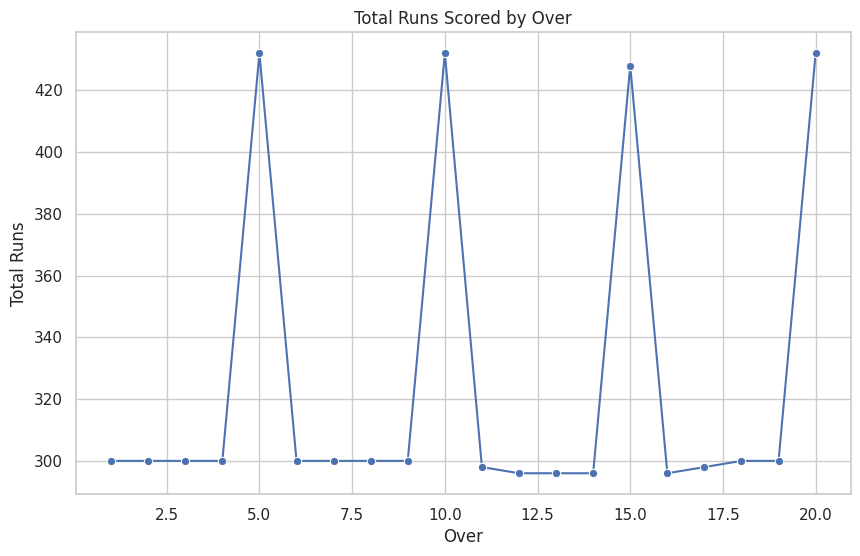

In [48]:
over_df = runs_per_over.reset_index()

over_df.columns = ['Over', 'Runs']

sns.lineplot(
    data=over_df,
    x='Over',
    y='Runs',
    marker='o'
)

plt.title('Total Runs Scored by Over')
plt.xlabel('Over')
plt.ylabel('Total Runs')
plt.show()

# **Step 27 — Average runs per over**

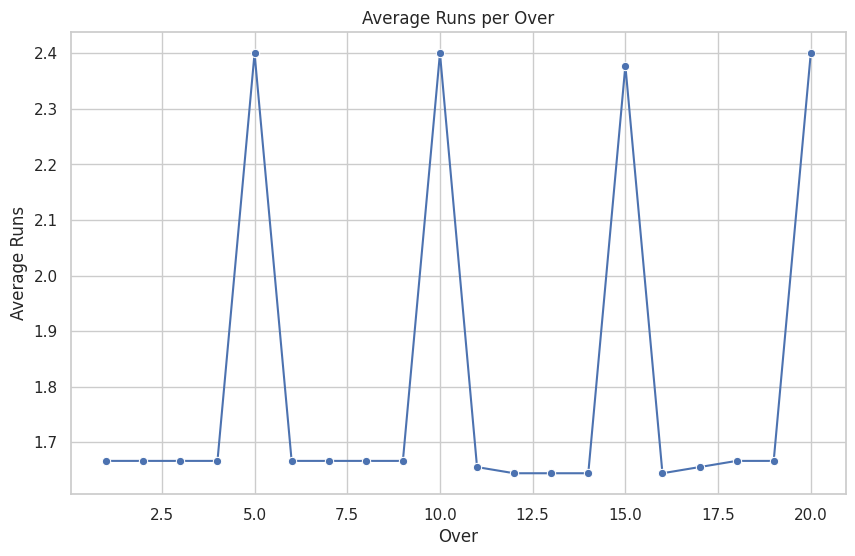

In [49]:
average_runs_over = (
    deliveries
    .groupby('over')['total_runs']
    .mean()
)

average_over_df = average_runs_over.reset_index()

average_over_df.columns = ['Over', 'Average Runs']

sns.lineplot(
    data=average_over_df,
    x='Over',
    y='Average Runs',
    marker='o'
)

plt.title('Average Runs per Over')
plt.xlabel('Over')
plt.ylabel('Average Runs')
plt.show()

# **Step 28 — Distribution of runs scored per ball**

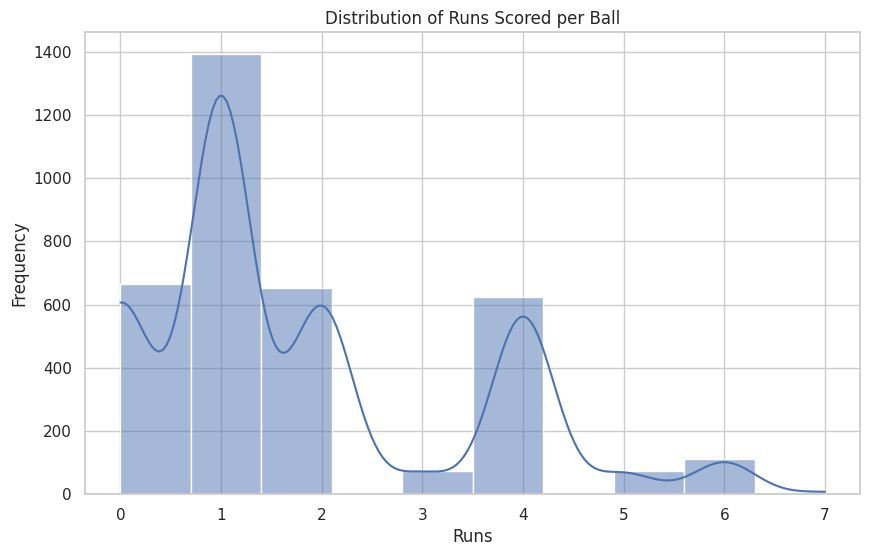

In [50]:
sns.histplot(
    data=deliveries,
    x='total_runs',
    bins=10,
    kde=True
)

plt.title('Distribution of Runs Scored per Ball')
plt.xlabel('Runs')
plt.ylabel('Frequency')
plt.show()

# **Step 29 — Box plot of runs per ball**

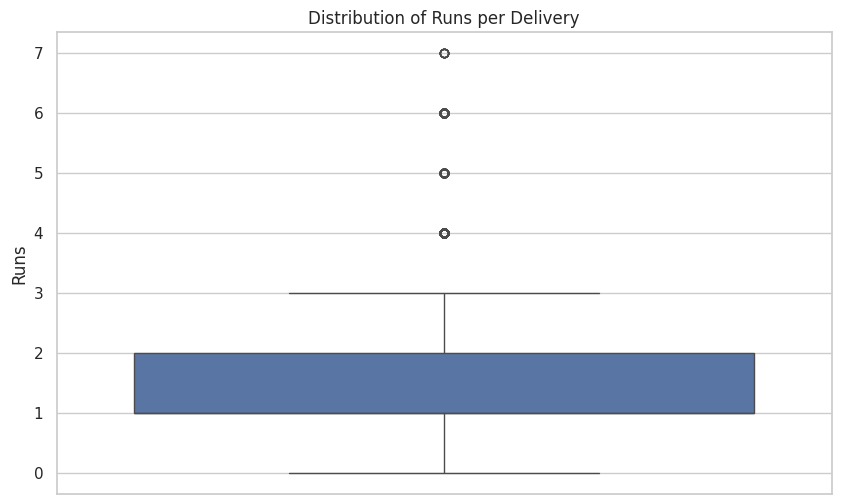

In [51]:
sns.boxplot(
    data=deliveries,
    y='total_runs'
)

plt.title('Distribution of Runs per Delivery')
plt.ylabel('Runs')
plt.show()

# **Step 30 — Team-wise scoring distribution**

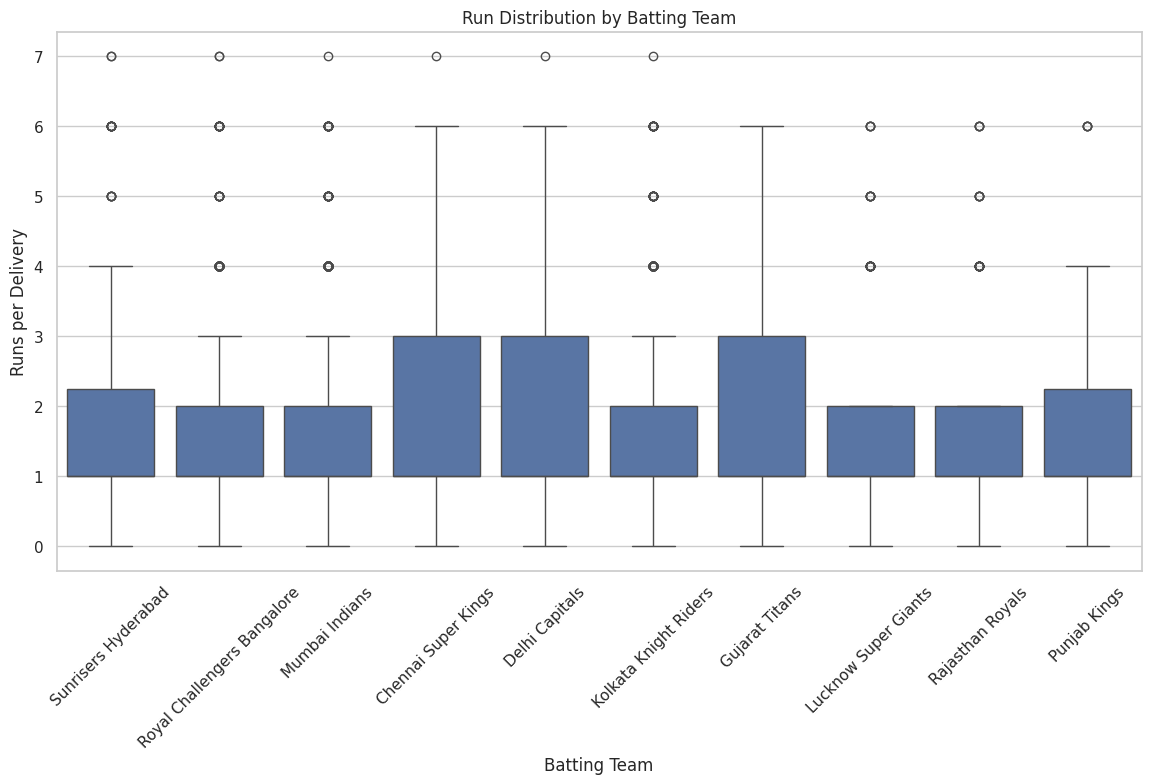

In [52]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=deliveries,
    x='batting_team',
    y='total_runs'
)

plt.title('Run Distribution by Batting Team')
plt.xlabel('Batting Team')
plt.ylabel('Runs per Delivery')
plt.xticks(rotation=45)

plt.show()

# **Step 31 — Batter runs vs number of balls**

**First calculate balls and runs:**

In [53]:
batter_stats = deliveries.groupby('batter').agg(
    Runs=('batsman_runs', 'sum'),
    Balls=('ball', 'count')
).reset_index()

**Remove players with very few deliveries:**

In [54]:
batter_stats = batter_stats[
    batter_stats['Balls'] >= 100
]

**Now plot:**

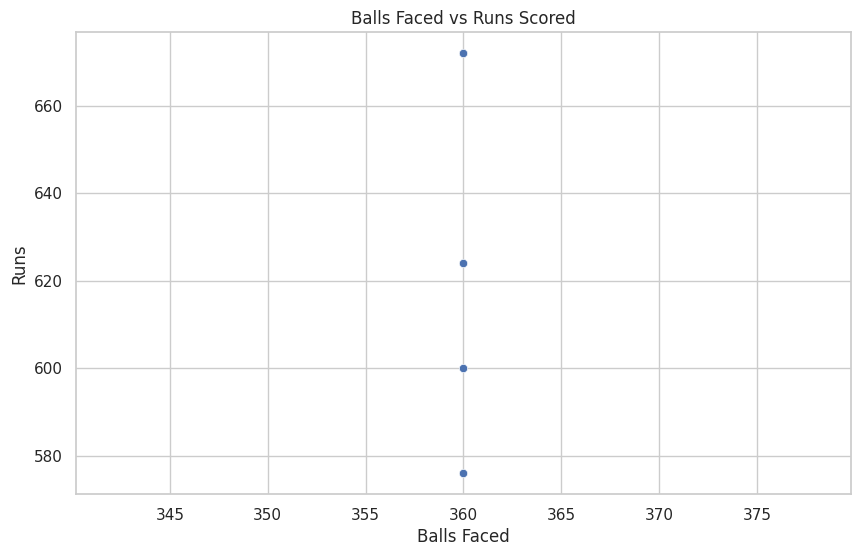

In [55]:
sns.scatterplot(
    data=batter_stats,
    x='Balls',
    y='Runs'
)

plt.title('Balls Faced vs Runs Scored')
plt.xlabel('Balls Faced')
plt.ylabel('Runs')
plt.show()

# **Step 32 — Add strike rate**

In [56]:
batter_stats['Strike_Rate'] = (
    batter_stats['Runs'] /
    batter_stats['Balls'] * 100
)

**view:**

In [57]:
batter_stats.sort_values(
    'Strike_Rate',
    ascending=False
).head(10)

,batter,Runs,Balls,Strike_Rate
9,Yashasvi Jaiswal,672,360,186.666667
3,MS Dhoni,672,360,186.666667
8,Virat Kohli,672,360,186.666667
6,Ruturaj Gaikwad,672,360,186.666667
4,Rishabh Pant,624,360,173.333333
7,Shubman Gill,624,360,173.333333
5,Rohit Sharma,600,360,166.666667
2,KL Rahul,600,360,166.666667
1,Andre Russell,576,360,160.000000
0,AB de Villiers,576,360,160.000000


# **Step 33 — Runs vs Strike Rate**

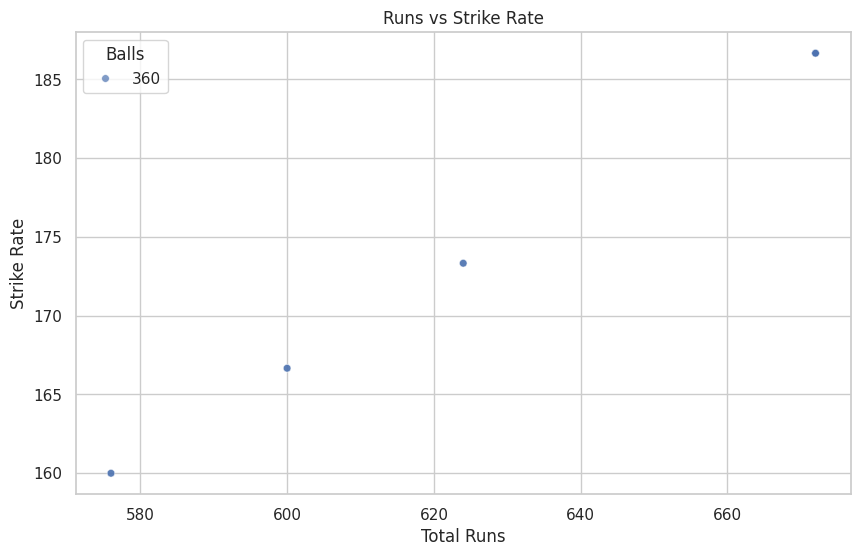

In [58]:
sns.scatterplot(
    data=batter_stats,
    x='Runs',
    y='Strike_Rate',
    size='Balls',
    sizes=(30, 300),
    alpha=0.7
)

plt.title('Runs vs Strike Rate')
plt.xlabel('Total Runs')
plt.ylabel('Strike Rate')
plt.show()

# **Step 34 — Team scoring comparison**

**Calculate runs by season and team:**

In [60]:
deliveries_with_season = pd.merge(
    deliveries,
    matches[['id', 'season']],
    left_on='match_id',
    right_on='id',
    how='left'
)

season_team_runs = (
    deliveries_with_season
    .groupby(['season', 'batting_team'])['total_runs']
    .sum()
    .reset_index()
)

In [61]:
print(season_team_runs.head())

   season                 batting_team  total_runs
0    2020          Chennai Super Kings         222
1    2020               Delhi Capitals         222
2    2020        Kolkata Knight Riders         218
3    2020               Mumbai Indians         206
4    2020  Royal Challengers Bangalore         206


# **Step 35 — Team performance by season**

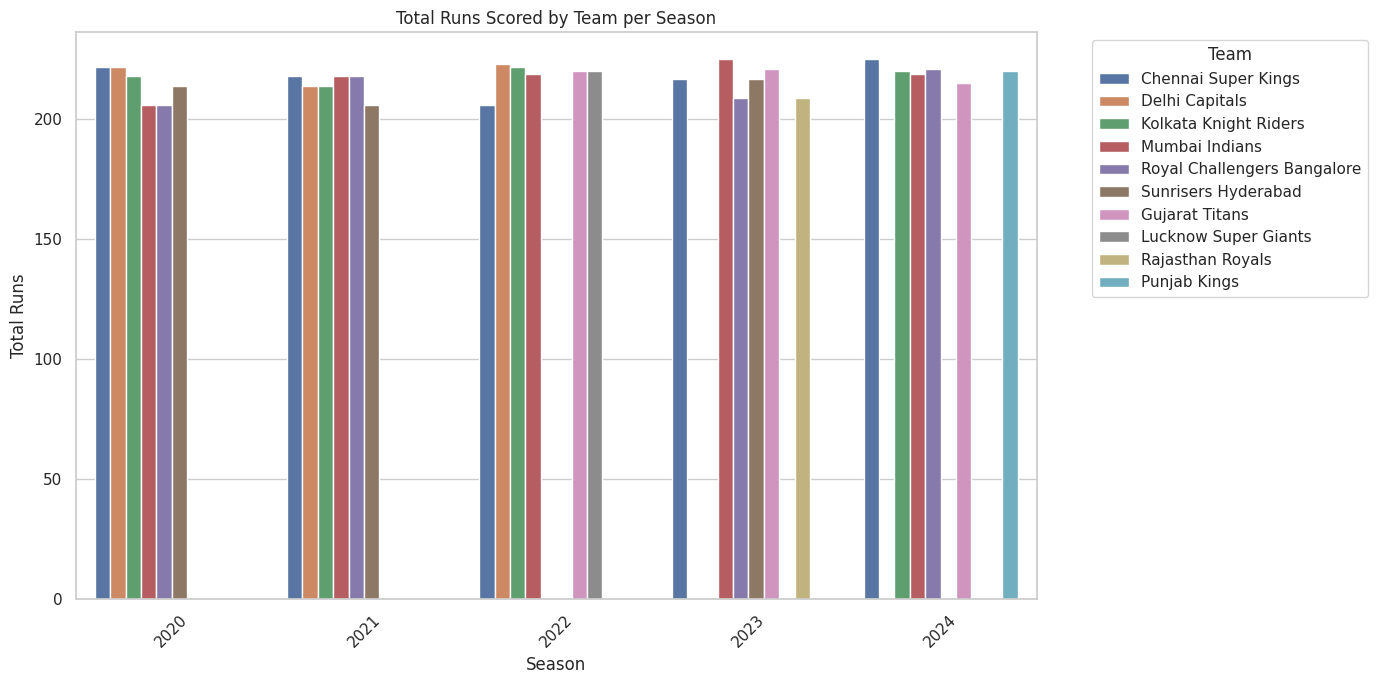

In [62]:
plt.figure(figsize=(14, 7))
sns.barplot(
    data=season_team_runs,
    x='season',
    y='total_runs',
    hue='batting_team'
)

plt.title('Total Runs Scored by Team per Season')
plt.xlabel('Season')
plt.ylabel('Total Runs')
plt.xticks(rotation=45)
plt.legend(title='Team', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# **Step 36 — Correlation analysis**

**Select numerical columns:**

In [63]:
numeric_columns = deliveries[
    ['over', 'ball', 'batsman_runs', 'extra_runs', 'total_runs']
]

**Calculate correlation:**

In [64]:
correlation = numeric_columns.corr()

print(correlation)

                      over          ball  batsman_runs    extra_runs  \
over          1.000000e+00 -2.815949e-17      0.032820 -1.703889e-02   
ball         -2.815949e-17  1.000000e+00      0.138515 -6.795804e-17   
batsman_runs  3.281972e-02  1.385152e-01      1.000000  1.054352e-01   
extra_runs   -1.703889e-02 -6.795804e-17      0.105435  1.000000e+00   
total_runs    2.940015e-02  1.348061e-01      0.988945  2.517269e-01   

              total_runs  
over            0.029400  
ball            0.134806  
batsman_runs    0.988945  
extra_runs      0.251727  
total_runs      1.000000  


# **Step 37 — Seaborn Heatmap 🔥**

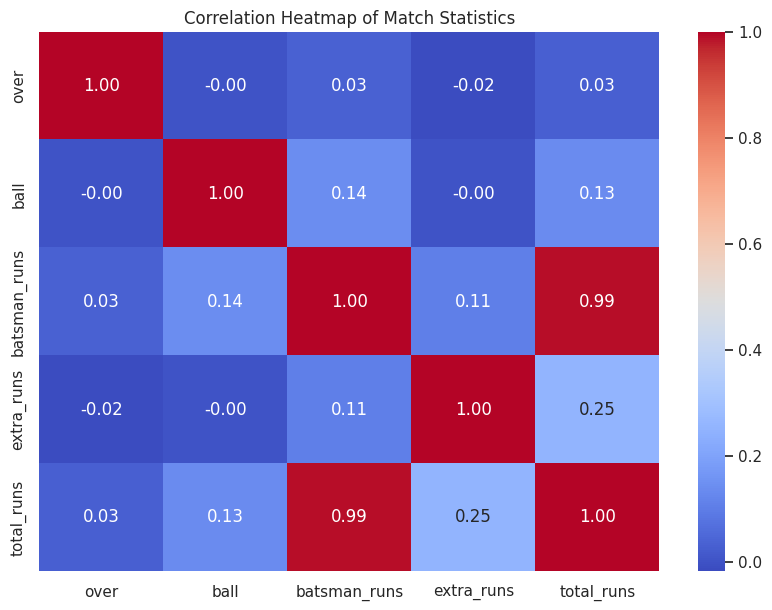

In [65]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Match Statistics')
plt.show()

# **Step 38 — Pairplot**

In [66]:
sample_data = deliveries[
    ['over', 'ball', 'batsman_runs', 'extra_runs', 'total_runs']
].sample(
    min(2000, len(deliveries)),
    random_state=42
)

**Create pairplot:**

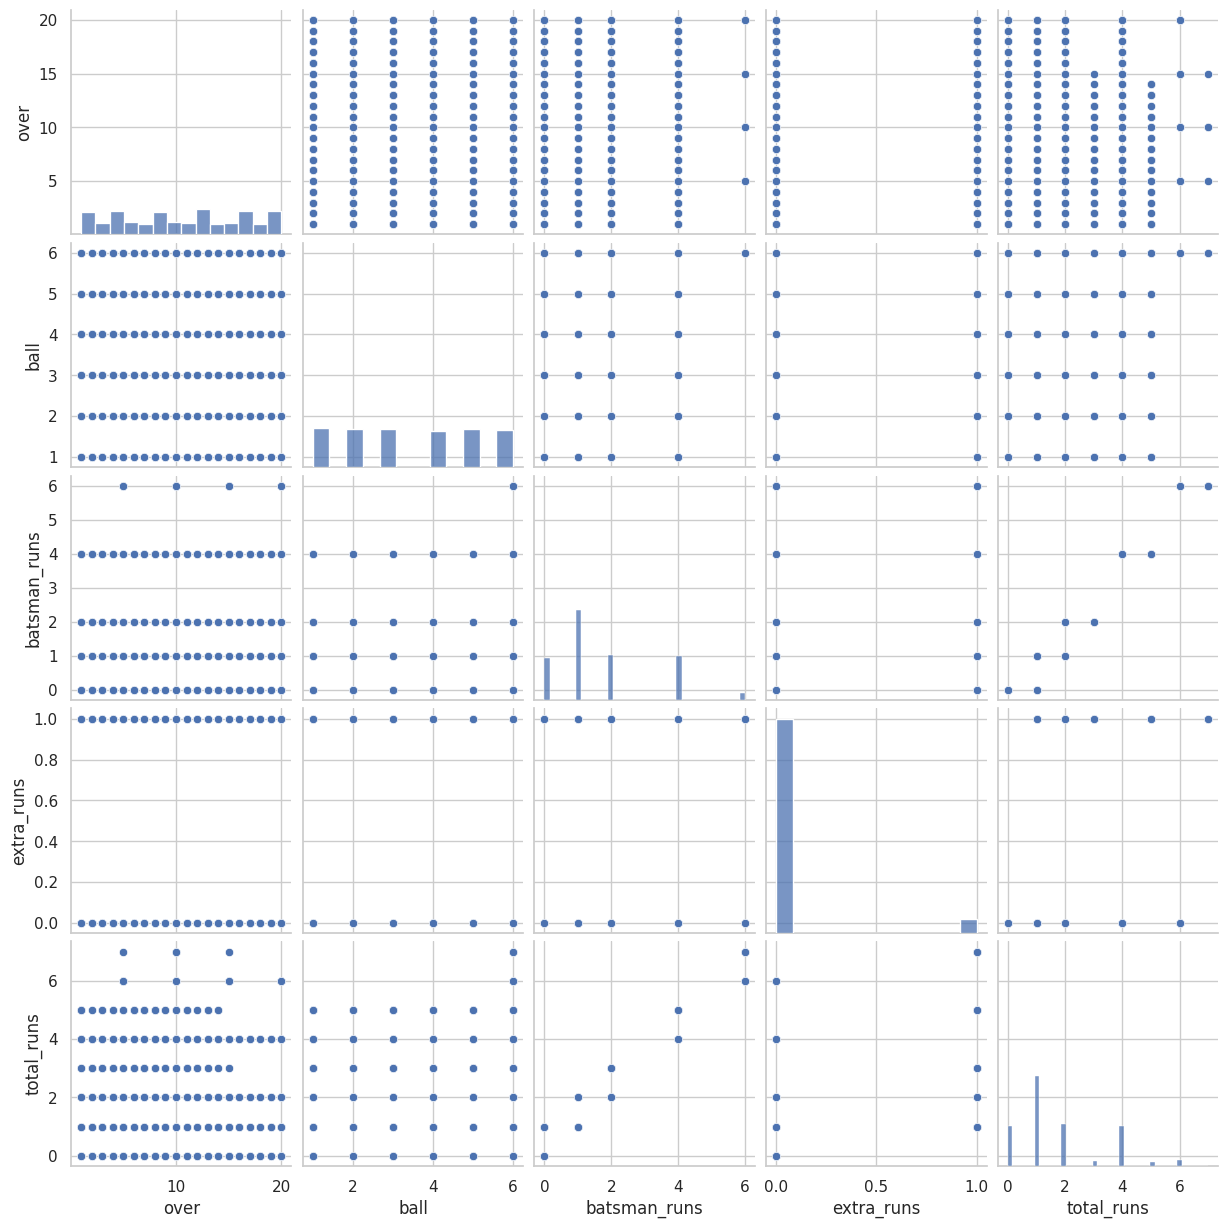

In [67]:
sns.pairplot(
    sample_data
)

plt.show()

# **Step 39 — Team win percentage**

In [68]:
team1 = matches['team1'].value_counts()
team2 = matches['team2'].value_counts()

matches_played = team1.add(team2, fill_value=0)

matches_won = matches['winner'].value_counts()

team_win_percentage = (
    matches_won / matches_played * 100
).sort_values(ascending=False)

print(team_win_percentage)

Delhi Capitals                 100.0
Gujarat Titans                 100.0
Rajasthan Royals               100.0
Kolkata Knight Riders           75.0
Royal Challengers Bangalore     75.0
Chennai Super Kings             40.0
Lucknow Super Giants             NaN
Mumbai Indians                   NaN
Punjab Kings                     NaN
Sunrisers Hyderabad              NaN
Name: count, dtype: float64


**Create DataFrame:**

In [69]:
win_percentage_df = (
    team_win_percentage
    .reset_index()
)

win_percentage_df.columns = [
    'Team',
    'Win_Percentage'
]

**Plot:**

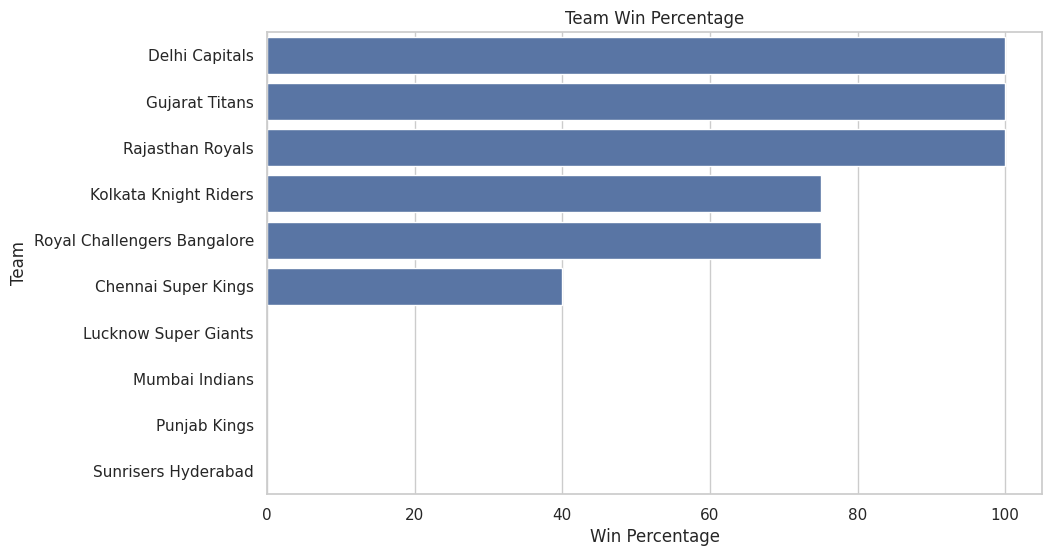

In [70]:
sns.barplot(
    data=win_percentage_df,
    x='Win_Percentage',
    y='Team'
)

plt.title('Team Win Percentage')
plt.xlabel('Win Percentage')
plt.ylabel('Team')
plt.show()

# **Step 40 — Winning margin analysis**

**Check:**

In [71]:
print(matches.columns.tolist())

['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'venue', 'player_of_match', 'win_by_runs', 'win_by_wickets', 'toss_match_winner']


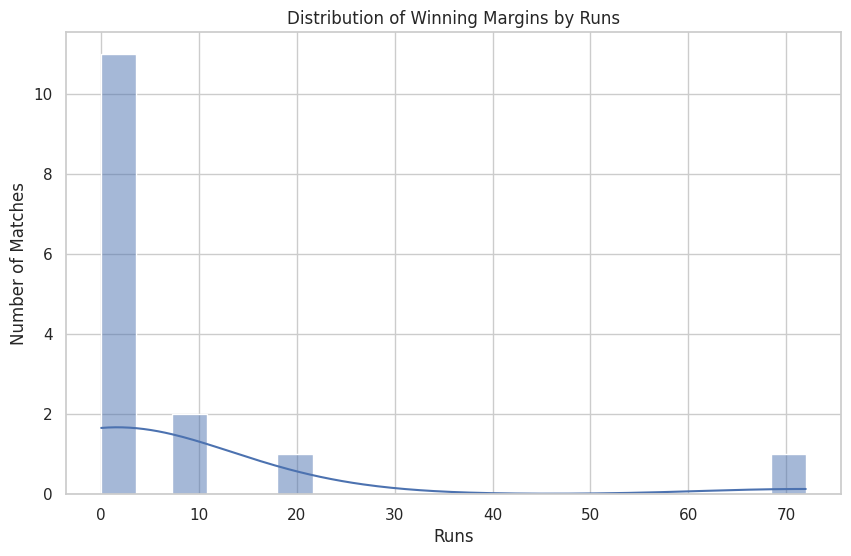

In [72]:
sns.histplot(
    data=matches,
    x='win_by_runs',
    bins=20,
    kde=True
)

plt.title('Distribution of Winning Margins by Runs')
plt.xlabel('Runs')
plt.ylabel('Number of Matches')

plt.show()

# **Step 41 — Runs vs wickets winning margin**

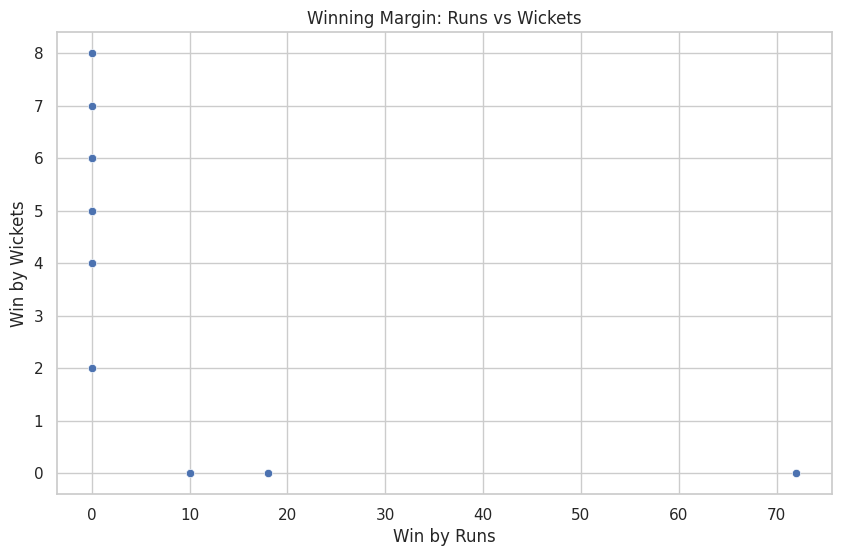

In [73]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=matches,
    x='win_by_runs',
    y='win_by_wickets'
)

plt.title('Winning Margin: Runs vs Wickets')
plt.xlabel('Win by Runs')
plt.ylabel('Win by Wickets')

plt.show()

# **Step 42 — Complete dashboard-style visualization**

**Chart 1 — Matches by season**

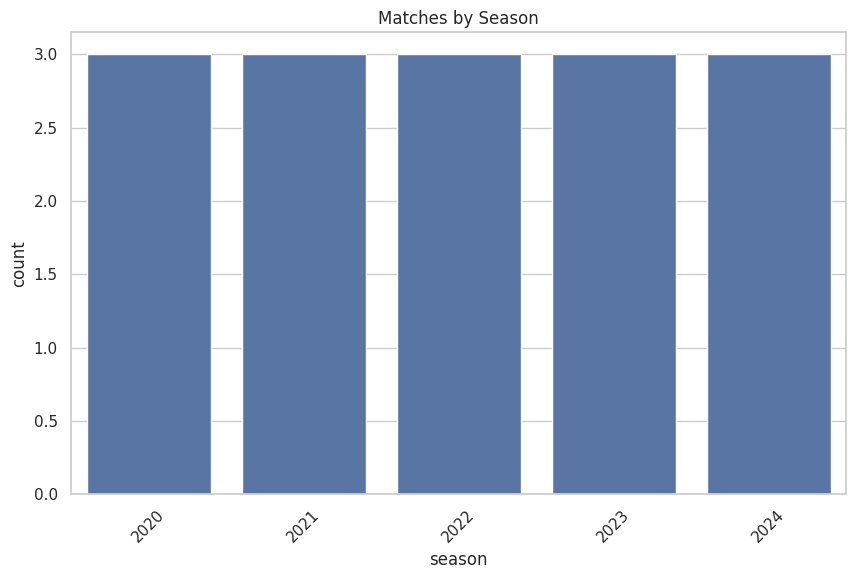

In [74]:
sns.countplot(
    data=matches,
    x='season'
)

plt.title('Matches by Season')
plt.xticks(rotation=45)
plt.show()

**Chart 2 — Team wins**

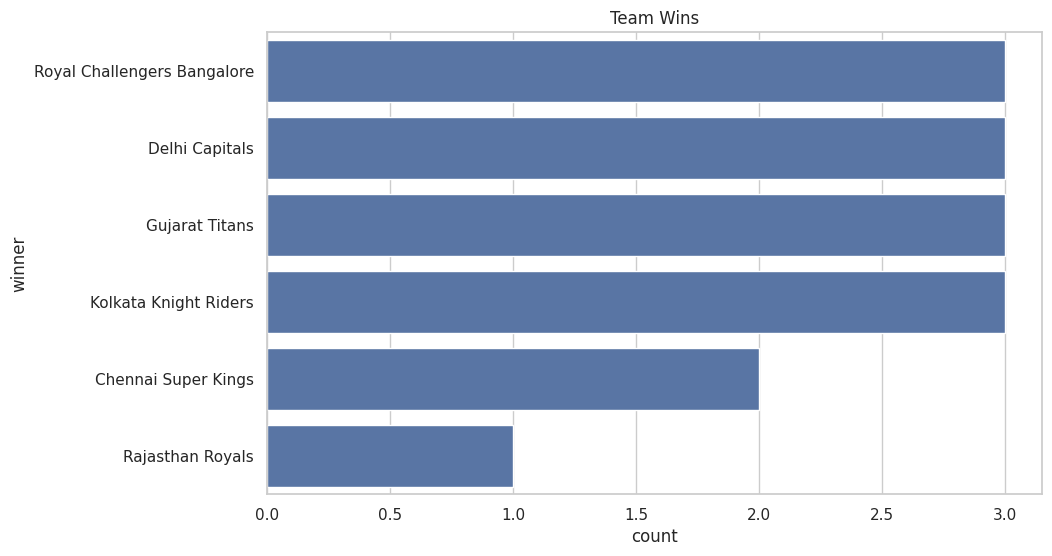

In [75]:
sns.countplot(
    data=matches,
    y='winner',
    order=matches['winner'].value_counts().index
)

plt.title('Team Wins')
plt.show()

**Chart 3 — Toss decisions**

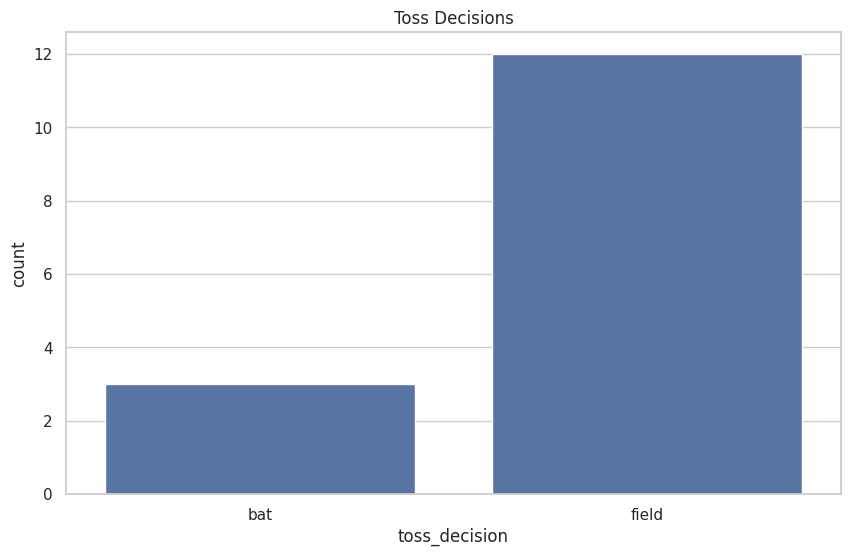

In [76]:
sns.countplot(
    data=matches,
    x='toss_decision'
)

plt.title('Toss Decisions')
plt.show()

**Chart 4 — Top run scorers**

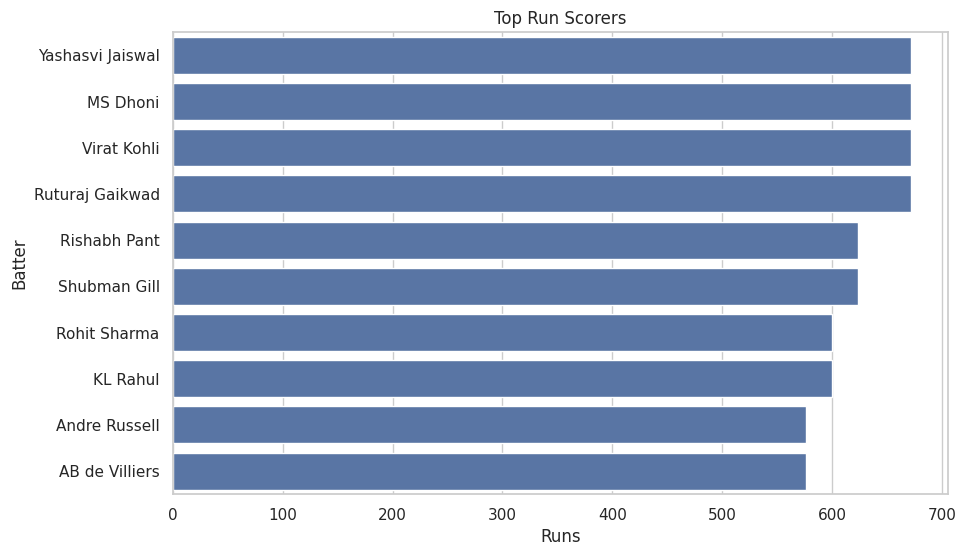

In [77]:
sns.barplot(
    data=top_batters,
    x='Runs',
    y='Batter'
)

plt.title('Top Run Scorers')
plt.show()

**Chart 5 — Top wicket takers**

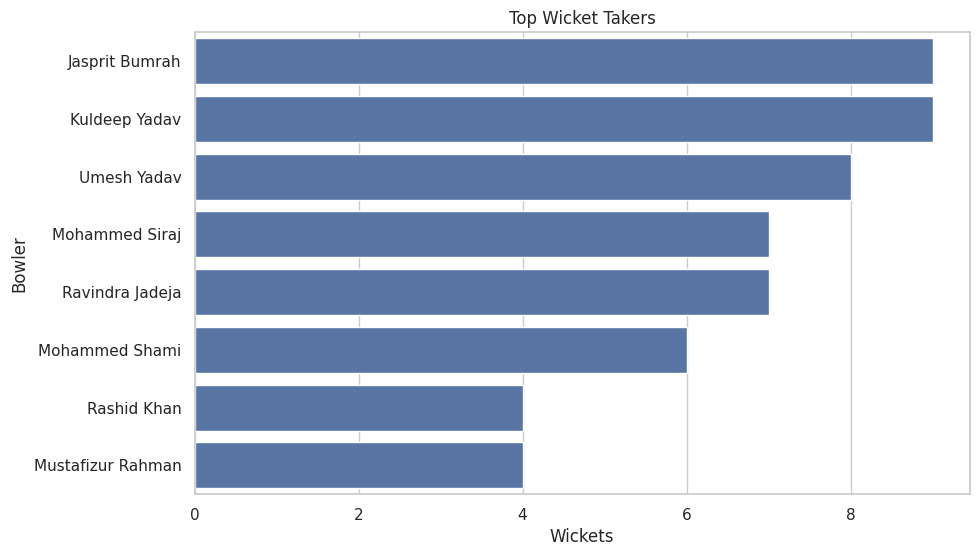

In [78]:
sns.barplot(
    data=wicket_df,
    x='Wickets',
    y='Bowler'
)

plt.title('Top Wicket Takers')
plt.show()